In [ ]:
!uv pip install openml
# changes
# more changesgit push



Using Python 3.13.12 environment at: /home/tatiana/Intro-ML/.venv
Audited 1 package in 3ms


In [17]:
import pandas as pd
import numpy as np

import openml
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_rows = 627920

# Load the dataset

pm_data = pd.read_csv('/home/tatiana/Intro-ML/ML_project/predictive_maintenance.csv')

# Inspect dataset

pm_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 950.2 KB


In [18]:
pm_data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.10,308.60,1551,42.80,0,0,No Failure
1,2,L47181,L,298.20,308.70,1408,46.30,3,0,No Failure
2,3,L47182,L,298.10,308.50,1498,49.40,5,0,No Failure
3,4,L47183,L,298.20,308.60,1433,39.50,7,0,No Failure
4,5,L47184,L,298.20,308.70,1408,40.00,9,0,No Failure


In [ ]:
pm_data.tail()
# changes

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
9995,9996,M24855,M,298.80,308.40,1604,29.50,14,0,No Failure
9996,9997,H39410,H,298.90,308.40,1632,31.80,17,0,No Failure
9997,9998,M24857,M,299.00,308.60,1645,33.40,22,0,No Failure
9998,9999,H39412,H,299.00,308.70,1408,48.50,25,0,No Failure
9999,10000,M24859,M,299.00,308.70,1500,40.20,30,0,No Failure


In [20]:
pd.set_option('display.float_format', '{:.2f}'.format)
pm_data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.00,310.01,1538.78,39.99,107.95,0.03
std,2886.90,2.00,1.48,179.28,9.97,63.65,0.18
min,1.00,295.30,305.70,1168.00,3.80,0.00,0.00
25%,2500.75,298.30,308.80,1423.00,33.20,53.00,0.00
50%,5000.50,300.10,310.10,1503.00,40.10,108.00,0.00
75%,7500.25,301.50,311.10,1612.00,46.80,162.00,0.00
max,10000.00,304.50,313.80,2886.00,76.60,253.00,1.00


In [21]:
pm_data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [22]:
pm_data_cleaned = pm_data.drop(['UDI','Product ID'], axis = 1)
pm_data_cleaned.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.10,308.60,1551,42.80,0,0,No Failure
1,L,298.20,308.70,1408,46.30,3,0,No Failure
2,L,298.10,308.50,1498,49.40,5,0,No Failure
3,L,298.20,308.60,1433,39.50,7,0,No Failure
4,L,298.20,308.70,1408,40.00,9,0,No Failure


In [23]:
failure_types = pm_data_cleaned['Failure Type'].unique()
print(failure_types)

<ArrowStringArray>
[              'No Failure',            'Power Failure',
        'Tool Wear Failure',       'Overstrain Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


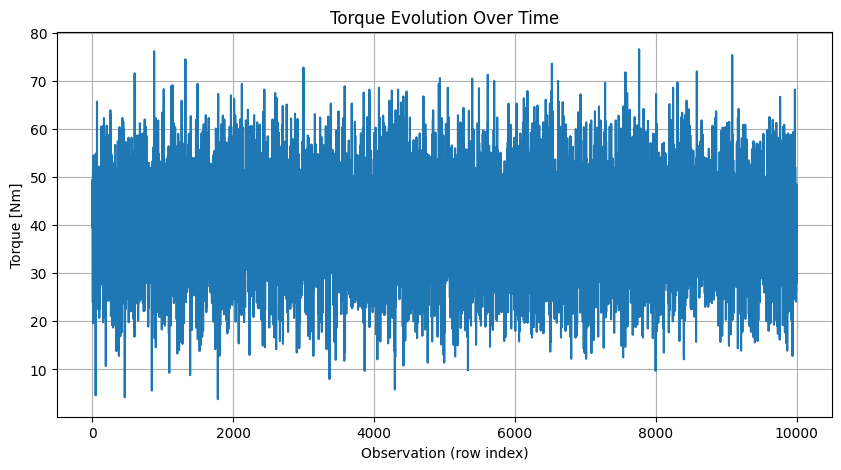

In [26]:
plt.figure(figsize=(10,5))
plt.plot(pm_data['Torque [Nm]'])  # adjust column name if needed

plt.title("Torque Evolution Over Time")
plt.xlabel("Observation (row index)")
plt.ylabel("Torque [Nm]")

plt.grid(True)
plt.show()

['No Failure', 'Power Failure', 'Tool Wear Failure', 'Overstrain Failure', 'Random Failures', 'Heat Dissipation Failure']


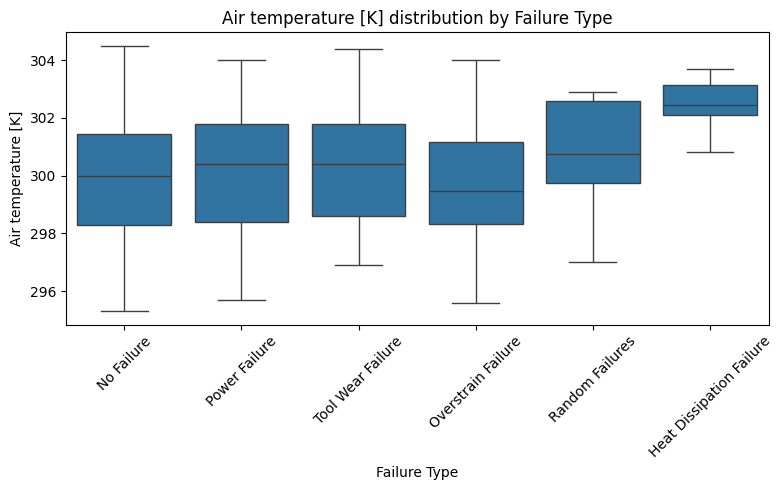

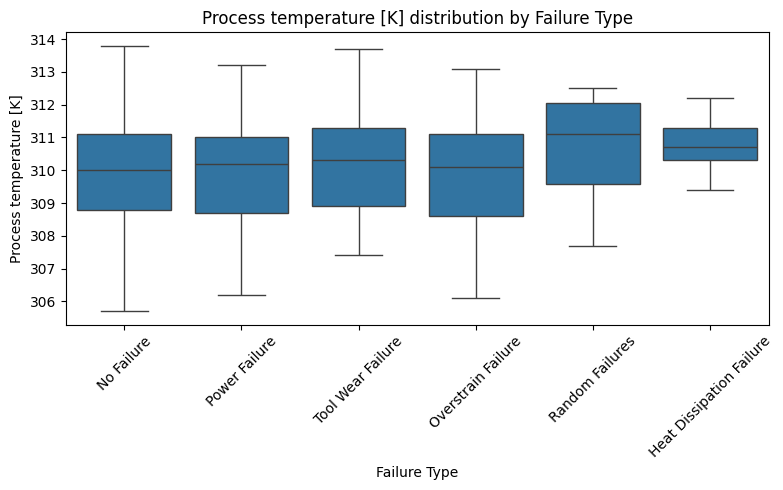

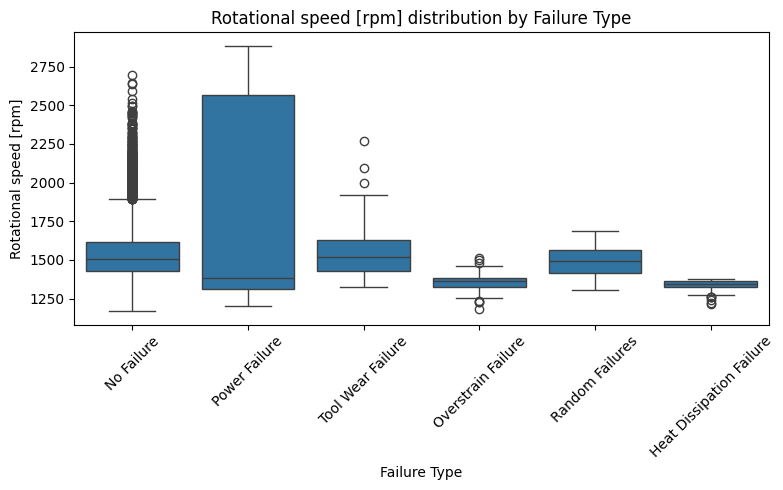

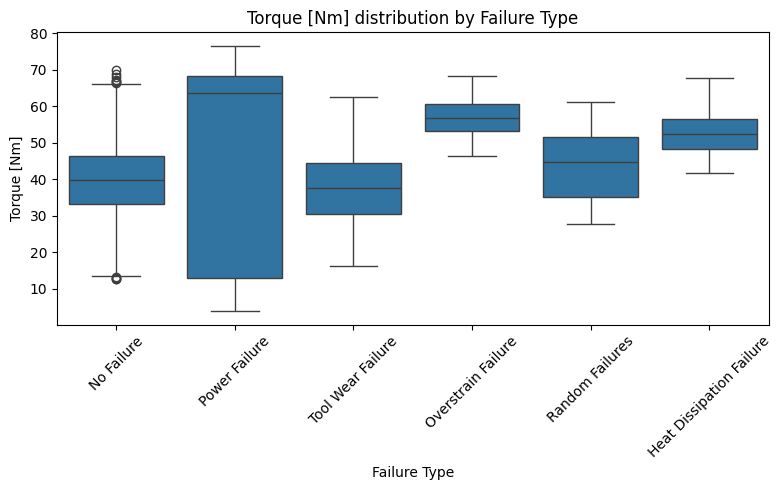

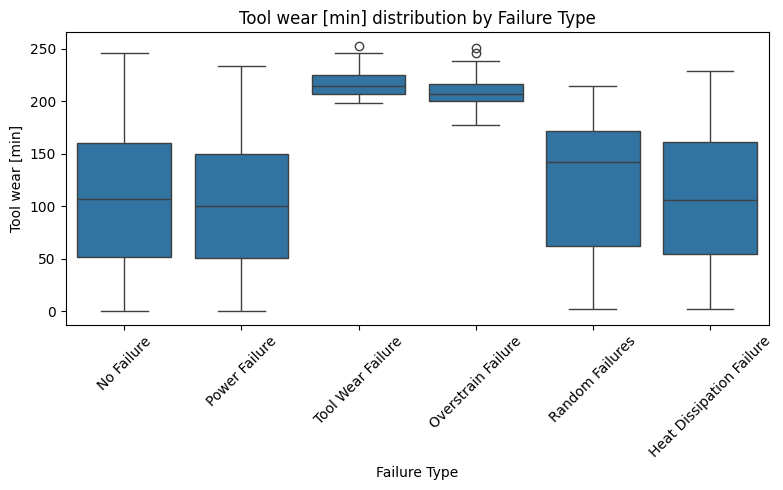

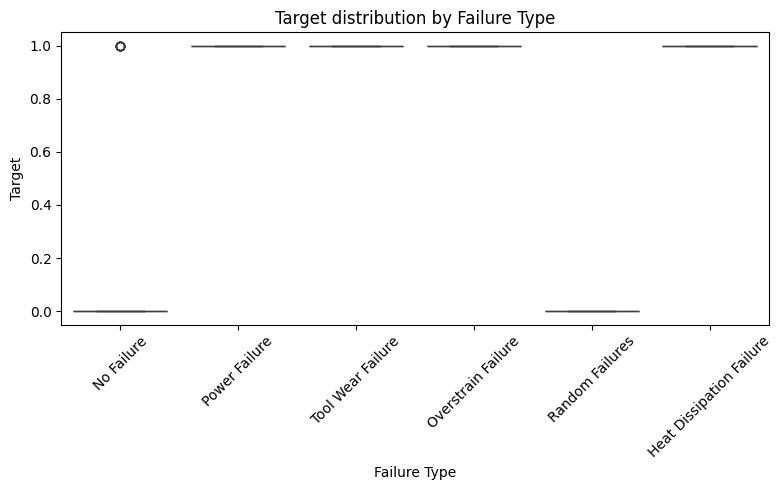

In [31]:
numeric_cols = pm_data_cleaned.select_dtypes(include=['number']).columns.tolist()

# define your target column
failure_types = pm_data['Failure Type'].unique().tolist()  # change to your column name
print(failure_types)

target = 'Failure Type'
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=target, y=col, data=pm_data_cleaned)
    
    plt.title(f'{col} distribution by {target}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

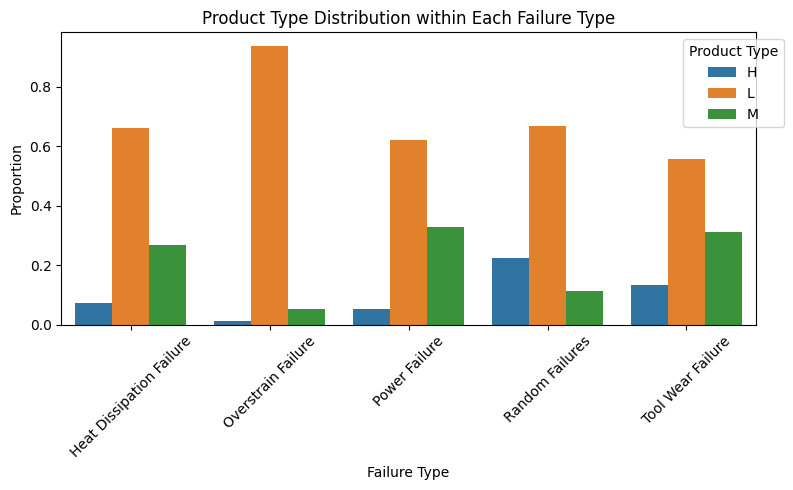

In [41]:
# Step 1: filter
filtered_df = pm_data_cleaned[
    pm_data_cleaned['Failure Type'] != 'No Failure'
]

# Step 2: contingency table (Failure → Product)
ct = pd.crosstab(
    filtered_df['Failure Type'],
    filtered_df['Type']
)

# Step 3: normalize per failure type
ct_norm = ct.div(ct.sum(axis=1), axis=0)

# Step 4: reshape for seaborn
ct_long = ct_norm.reset_index().melt(
    id_vars='Failure Type',
    var_name='Product Type',
    value_name='Proportion'
)

# Step 5: plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=ct_long,
    x='Failure Type',
    y='Proportion',
    hue='Product Type'
)

plt.title("Product Type Distribution within Each Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.legend(title="Product Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

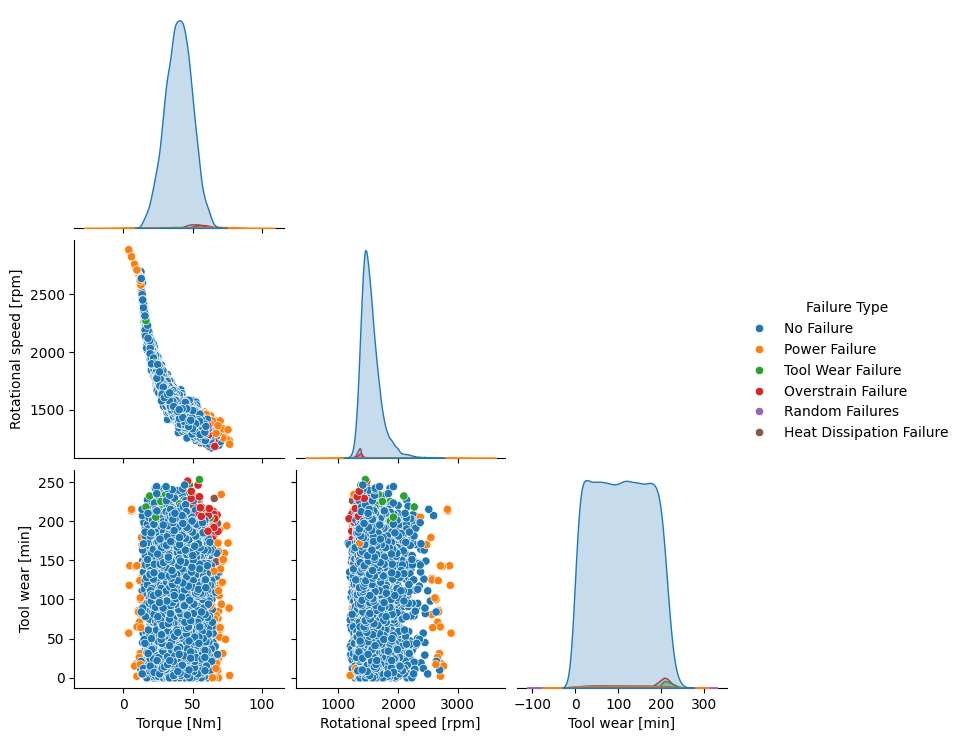

In [42]:
sns.pairplot(
    pm_data_cleaned,
    vars=['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]'],
    hue='Failure Type',
    corner=True
)

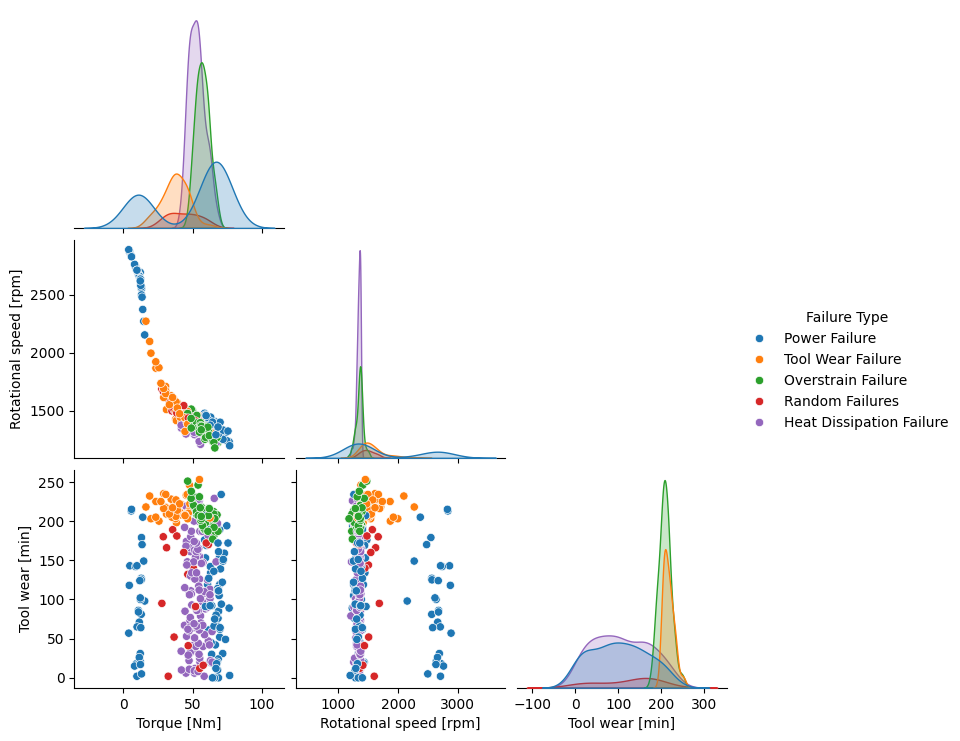

In [45]:
sns.pairplot(
    filtered_df,
    vars=['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]'],
    hue='Failure Type',
    corner=True
)

In [53]:
import plotly.express as px

fig = px.scatter_3d(
    pm_data_cleaned,
    x='Tool wear [min]',
    y='Torque [Nm]',
    z='Rotational speed [rpm]',
    color='Failure Type',
    opacity=0.6
)

fig.update_layout(title="3D Interaction of Features")
fig.show()

ModuleNotFoundError: No module named 'plotly'

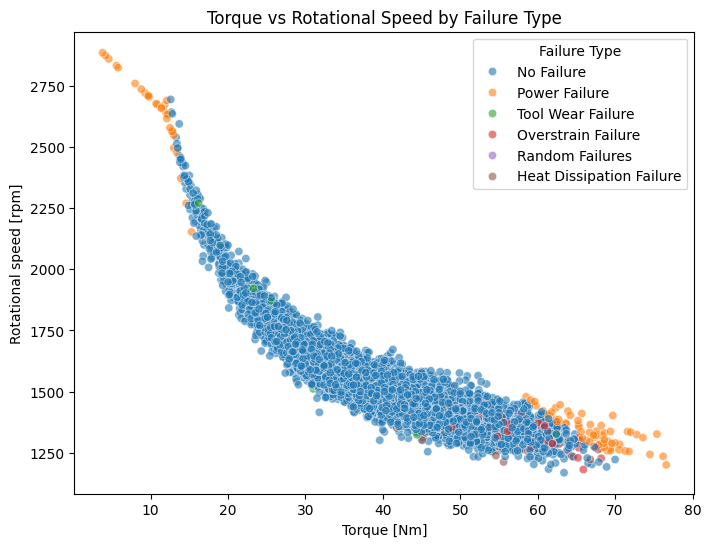

In [43]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pm_data_cleaned,
    x='Torque [Nm]',
    y='Rotational speed [rpm]',
    hue='Failure Type',
    alpha=0.6
)

plt.title("Torque vs Rotational Speed by Failure Type")
plt.show()

<Axes: xlabel='Tool wear [min]', ylabel='Torque [Nm]'>

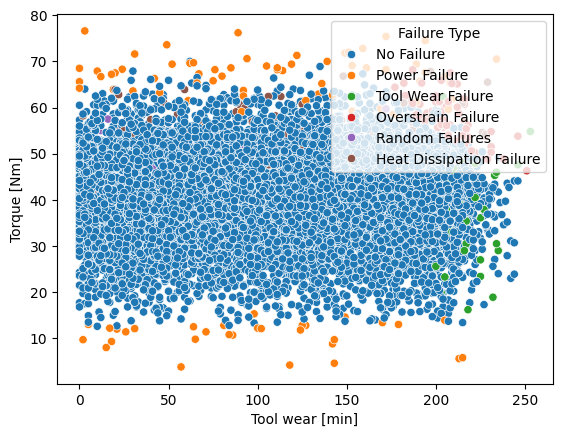

In [44]:
sns.scatterplot(
    data=pm_data_cleaned,
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='Failure Type'
)

In [47]:
# Flag reset
pm_data_cleaned['tool_reset'] = (
    pm_data_cleaned['Tool wear [min]'].diff() < -100
)
# create cycle id
pm_data_cleaned['cycle_id'] = pm_data_cleaned['tool_reset'].cumsum()

# normalise with each cycle
pm_data_cleaned['tool_wear_normalized'] = (
    pm_data_cleaned.groupby('cycle_id')['Tool wear [min]'].transform(lambda x: x / x.max()))


pm_data_cleaned['is_near_failure'] = (
    pm_data_cleaned['Tool wear [min]'] > 180
).astype(int)

pm_data_cleaned.head()
    

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,tool_reset,cycle_id,tool_wear_normalized,is_near_failure
0,M,298.10,308.60,1551,42.80,0,0,No Failure,False,0,0.00,0
1,L,298.20,308.70,1408,46.30,3,0,No Failure,False,0,0.01,0
2,L,298.10,308.50,1498,49.40,5,0,No Failure,False,0,0.02,0
3,L,298.20,308.60,1433,39.50,7,0,No Failure,False,0,0.03,0
4,L,298.20,308.70,1408,40.00,9,0,No Failure,False,0,0.04,0


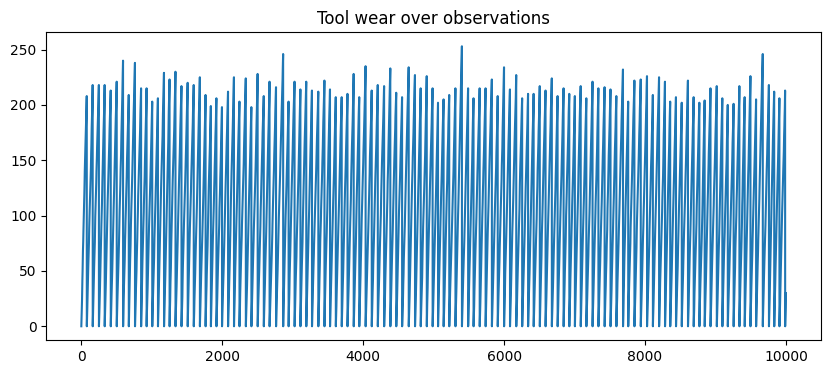

In [48]:
plt.figure(figsize=(10, 4))
plt.plot(pm_data_cleaned['Tool wear [min]'])
plt.title("Tool wear over observations")
plt.show()

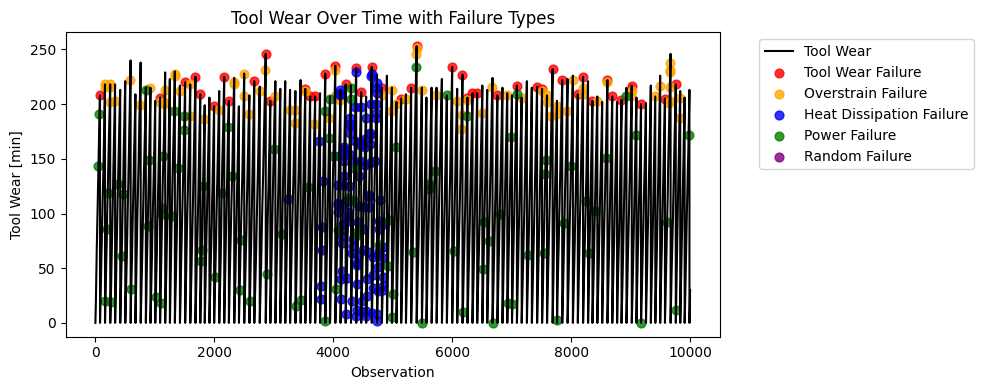

In [51]:
plt.figure(figsize=(10, 4))

# Plot the tool wear line
plt.plot(pm_data_cleaned['Tool wear [min]'], color='black', label='Tool Wear')

# Define colors per failure type
colors = {
    'Tool Wear Failure': 'red',
    'Overstrain Failure': 'orange',
    'Heat Dissipation Failure': 'blue',
    'Power Failure': 'green',
    'Random Failure': 'purple'
}

# Loop through failure types
for ft, color in colors.items():
    subset = pm_data_cleaned[pm_data_cleaned['Failure Type'] == ft]
    
    plt.scatter(
        subset.index,
        subset['Tool wear [min]'],
        color=color,
        label=ft,
        alpha=0.8,
        s=40
    )

plt.title("Tool Wear Over Time with Failure Types")
plt.xlabel("Observation")
plt.ylabel("Tool Wear [min]")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Axes: xlabel='Failure Type', ylabel='Tool wear [min]'>

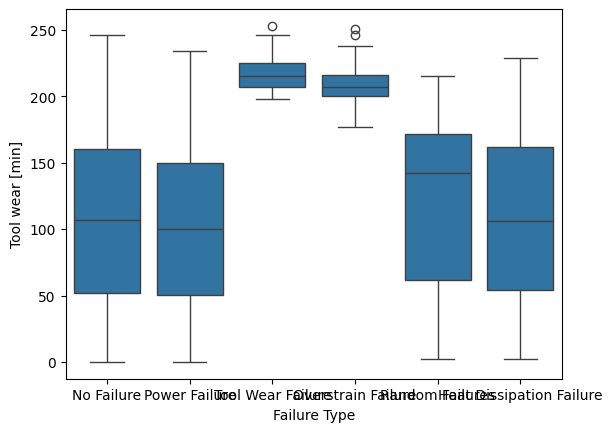

In [49]:
sns.boxplot(
    x='Failure Type',
    y='Tool wear [min]',
    data=pm_data_cleaned
)